# Домашнее задание 2. Работа с изображениями

В этом задании предлагается решить простейшую задачу рапознавания лиц. Вам нужно будет научить модель для пары картинок определять, разные ли люди на них изображены.

Работать будем с датасетом фотографий известных людей. Скачать его можно [тут](https://disk.360.yandex.ru/d/oAmJgPESjP33hg). В нём представлены 150 человек, для каждого по 6-9 фотографий. Всего около 1000 изображений.

__Задание__. Вам потребуется выполнить два задания:

1) Реализовать модель бинарной классификации и добиться приемлемого качества.

2) Реализовать триплетную функцию потерь и улучшить качество предсказаний с ее помощью.

Напишите краткий отчёт о проделанных экспериментах. Что сработало и что не сработало? Почему вы решили, сделать так, а не иначе? Обязательно указывайте ссылки на чужой код, если вы его используете. Обязательно ссылайтесь на статьи / блогпосты / вопросы на stackoverflow / видосы от ютуберов-машинлернеров / курсы / подсказки от Дяди Васи и прочие дополнительные материалы, если вы их используете.

__Во всех заданиях будем придерживаться следующих правил__:
1. Использовать внешние данные для обучения строго запрещено. Также запрещено обучаться на валидационной выборке.
2. Все задания должны быть выполнены без использования предобученных моделей и готовых реализаций. Тем не менее:
    - В заданиях, где требуется достичь некоторого качества модели, разрешается использовать предобученные модели. Но __оценка за задние будет снижена__ (для каждого задания будет отдельно указано, на сколько).
    - В некоторых заданиях может сильно помочь библотека [pytorch-metric-learning](https://kevinmusgrave.github.io/pytorch-metric-learning/). Вы можете использовать готовые реализации из неё, но __максимальный балл за задание также будет снижен__.

__Советы и указания__:
 - Наверняка вам потребуется много гуглить о том, как заставить это всё работать. Это нормально, все гуглят. Но не забывайте, что нужно быть готовым за скатанный код отвечать :)
 - Рекомендуем использовать шаблоны ниже. Однако делать это мы не заставляем. Если вам так неудобно, то можете писать код в удобном стиле. Однако учтите, что чрезмерное изменение нижеперечисленных шаблонов увеличит количество вопросов к вашему коду :)
 - Валидируйте. Трекайте ошибки как можно раньше, чтобы не тратить время впустую.
 - Чтобы быстро отладить код, пробуйте обучаться на маленькой части датасета (скажем, 5-10 картинок просто чтобы убедиться что код запускается). Когда вы поняли, что смогли всё отдебажить, переходите обучению по всему датасету
 - На каждый запуск делайте ровно одно изменение в модели/аугментации/оптимайзере, чтобы понять, что и как влияет на результат.
 - Фиксируйте random seed.
 - Правильно нормализуйте данные при создании, пример [тык, но тут и в целом гайд от и до](https://www.pluralsight.com/guides/image-classification-with-pytorch)
 - Начинайте с простых моделей и постепенно переходите к сложным. Обучение лёгких моделей экономит много времени. Можно написать свою модель руками, а можно импортировать не предобученную сетку известной архитектуры из модуля `torchvision.models`. Один из способов как можно сделать: [документация (полезная)](https://pytorch.org/vision/stable/models.html)
 - Используйте все возможные методы оптимизации и эксперемнтируйте с ними.
 - Ставьте расписание на learning rate. Уменьшайте его, когда лосс на валидации перестаёт убывать.
 - Model Checkpointing. Сохраняйте свой прогресс (модели), чтобы когда что-то пойдет не так вы сможете начать с этого места или просто воспроизвести свои результаты модели, которые обучали.
    * Пример как можно с wandb тут: [Сохраняем лучшие модели в wandb](https://docs.wandb.ai/guides/integrations/lightning)
    * По простому можно так: [Сохраняем модели в pytorch дока](https://pytorch.org/tutorials/beginner/saving_loading_models.html)
 - Советуем использовать GPU. Если у вас его нет, используйте google colab. Если вам неудобно его использовать на постоянной основе, напишите и отладьте весь код локально на CPU, а затем запустите уже написанный ноутбук в колабе.

Good luck & have fun! :)

In [4]:
import os
import tqdm
import shutil
import numpy as np
import torch
import sys
import pandas as pd
import random
import torchvision
import sklearn.metrics
import torch.utils.data
import matplotlib.pyplot as plt
import torchvision.transforms.v2 as transforms
from sklearn.model_selection import train_test_split
from torch import nn
from IPython.display import clear_output
from tqdm.auto import tqdm, trange
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import defaultdict

In [32]:
# Обязательно вызывайте эту функцию перед каждый запуском обучения!
# Если проверяющий не сможет воспроизвести результат, оценка за задание будет снижена.
def set_random_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    torch.backends.cudnn.deterministic = True

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


### [1.5 балла] Часть 1. Подготовка данных.

##### [0.5 балла] Задание 1.1. Считать датасет.

Сначала нужно считать датасет с фотографиями и посмотреть на его устройство.

In [ ]:
from google.colab import files
uploaded = files.upload()

In [5]:
!unzip /content/data.zip -d /content/celeb_data/

unzip:  cannot find or open /content/data.zip, /content/data.zip.zip or /content/data.zip.ZIP.


In [13]:
shutil.move('/content/celeb_data/data/training', '/content/celeb_data/')
shutil.move('/content/celeb_data/data/testing', '/content/celeb_data/')
shutil.rmtree('/content/celeb_data/data')

FileNotFoundError: [Errno 2] No such file or directory: '/content/celeb_data/data/training'

In [ ]:
!rm /content/data.zip

In [85]:
train_valid_ds = torchvision.datasets.ImageFolder("celeb_data/training", transform=torchvision.transforms.v2.ToTensor())

/usr/local/lib/python3.11/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(


FileNotFoundError: [Errno 2] No such file or directory: 'celeb_data/training'

In [86]:
train_valid_ds = torchvision.datasets.ImageFolder("/kaggle/input/data-zip/data/training", transform=torchvision.transforms.v2.ToTensor())

Для начала подготовим данные - вычислим средние и стандартные отклонения для нормализации тренировочного и тестового датасетов. Так как тренировочная и валидационная выборки изначально находятся в одном датасете и, следовательно, имеют одинаковое распределение (при условии случайного выбора), то подсчитаем общие статистики.

In [89]:
mean = torch.zeros(3)
std = torch.zeros(3)
ims = 0
train_valid_ds_temp_ld = torch.utils.data.DataLoader(train_valid_ds,batch_size=32, shuffle=False)
for im, t in train_valid_ds_temp_ld:
  sz = im.size(0)
  fl = im.view(sz, 3, -1)
  mean += fl.mean(2).sum(0)
  std += fl.std(2).sum(0)
  ims += sz
means_tvl = mean / ims
stds_tvl = std / ims
del train_valid_ds_temp_ld
print(means_tvl.tolist())
print(stds_tvl.tolist())

[0.4298853576183319, 0.374708354473114, 0.3324360251426697]
[0.27030330896377563, 0.2435230165719986, 0.2338455468416214]


Нормализуем датасеты на основе полученных данных. Отдельная трансформация для тренировочной и валидационной выборок, находящихся в одном и том же датасете, иная для тестовых данных. Добавленные аугментации должны позволять модели легче искать паттерны на изображениях и быстрее обучаться. Тестовая выборка, соответственно, преобразовываться не будет.

На основе:
1) Семинар 2: https://colab.research.google.com/drive/1n6z6G_9T1yOSt2UHV3Y5aic54AygfnUK?usp=sharing#scrollTo=XNeqKf_4Ez32
2) Image Classification with PyTorch: https://www.pluralsight.com/resources/blog/guides/image-classification-with-pytorch

In [90]:
transform_train = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=means_tvl, std=stds_tvl)
])

transform_val_test = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=means_tvl, std=stds_tvl)
])

In [91]:
train_valid_ds_tr = torchvision.datasets.ImageFolder("celeb_data/training", transform=transform_val_test)  
test_ds_tr = torchvision.datasets.ImageFolder("celeb_data/testing", transform=transform_val_test)

FileNotFoundError: [Errno 2] No such file or directory: 'celeb_data/training'

In [92]:
train_valid_ds_tr = torchvision.datasets.ImageFolder("/kaggle/input/data-zip/data/training", transform=transform_val_test)  
test_ds_tr = torchvision.datasets.ImageFolder("/kaggle/input/data-zip/data/testing", transform=transform_val_test)

Разделим тренировочный датасет на тренировочную и валидационные части. Преобразуем subset в формат частичного Dataset - добавив функционал извлечения таргетов, что необходимо для формирования пар в дальнейшем.

In [93]:
set_random_seed(42)
train_subset, valid_subset = torch.utils.data.random_split(train_valid_ds_tr, [0.9, 0.1])
train_subset.dataset.transform = transform_train 
valid_subset.dataset.transform = transform_val_test
train_leng = len(train_subset)
valid_leng = len(valid_subset)
train_ind = np.arange(train_leng)
valid_ind = np.arange(valid_leng)
class SubsettoDataset(torch.utils.data.Dataset):
    def __init__(self, source_dataset, indices):
        self.samples = []
        self.targets = []
        for idx in indices:
            img, target = source_dataset[idx]
            self.samples.append((img, target))
            self.targets.append(target)
    def __len__(self):
        return len(self.samples)
    def __getitem__(self, idx):
        return self.samples[idx]
train_ds = SubsettoDataset(train_subset, train_ind)
valid_ds = SubsettoDataset(valid_subset, valid_ind)

Давайте посмотрим на примеры фотографий. Нарисуйте несколько.

Здесь фотографии будут нарисованы из оригинального датасета.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping i

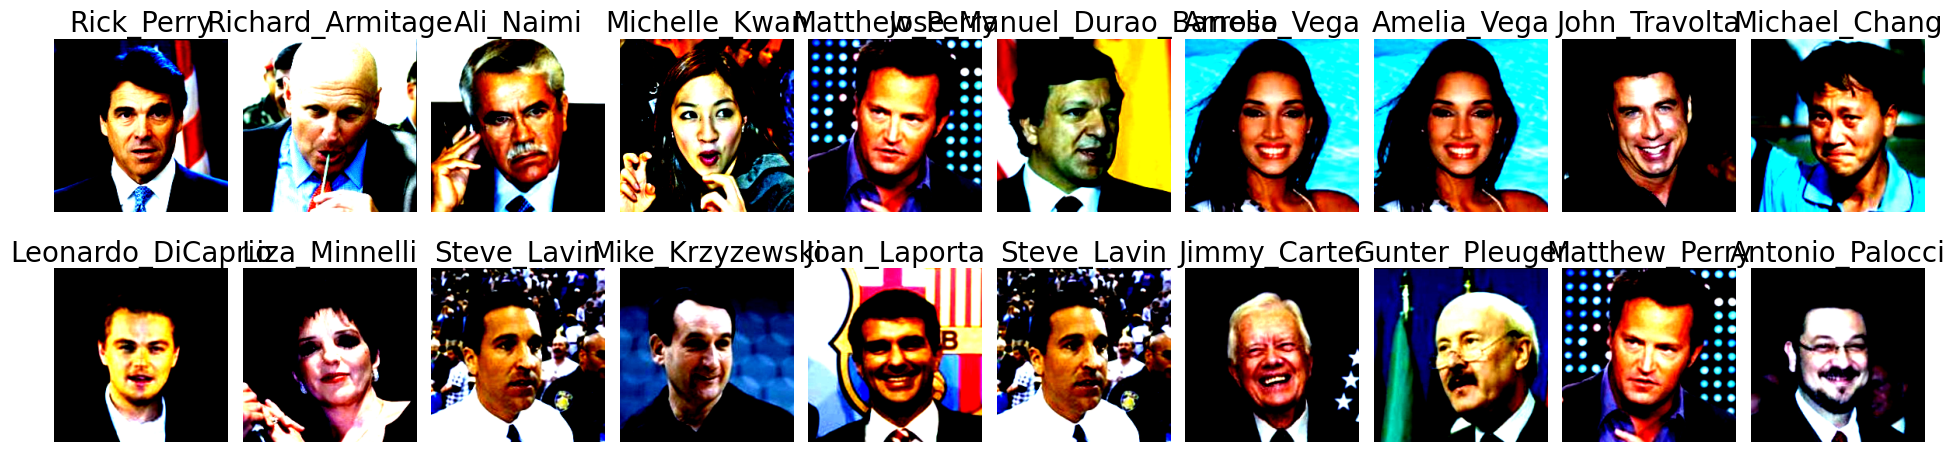

In [97]:
set_random_seed(42)
fig, axes = plt.subplots(2, 10, figsize=(19, 5))
ans = np.random.randint(1, 87, 20)
for idx, ax in enumerate(axes.flatten()):
      img_tensor, label = train_ds[ans[idx]]
      img = np.transpose(img_tensor, (1, 2, 0))
      ax.imshow(img)
      ax.set_title(train_valid_ds.classes[label], fontsize=20, pad=2)
      ax.axis('off')
plt.tight_layout()
plt.show()

Наконец, следует вывести распределение фотографий по людям и убедиться, что для каждого человека действительно предствалено 6-9 фотографий.

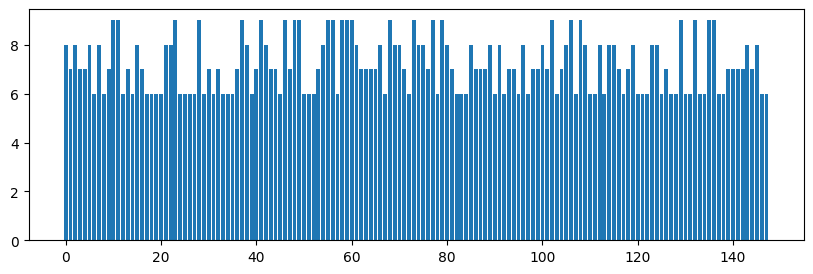

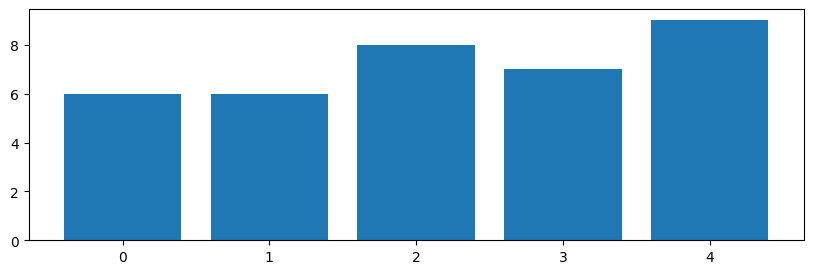

In [98]:
def show_class_distribtion(targets):
  uniques, counts = np.unique(targets, return_counts=True)
  fig = plt.subplots(figsize =(10, 3))
  plt.bar(uniques, counts)
  plt.show()


show_class_distribtion(train_valid_ds.targets)
show_class_distribtion(test_ds_tr.targets)

##### [0 баллов] Задание 1.2. Датасет пар.

Как было сказано ранее, мы будем обучать модели предсказывать, разные ли люди изображены на фотографиях. Для этого нам надо научиться формировать пары фотографий и целевую переменную из двух классов: 0 и 1. \
Класс 0 означает, что это фотографии одного человека. \
Класс 1 означает фотографии разных людей. \
 \
К счастью, весь датасет уже написан.

In [99]:
class PairDataset(torch.utils.data.Dataset):
    def __init__(self, dataset):
        self.dataset = dataset
        self.targets = [self._get_target(i) for i in range(len(self)) ]

    def _idx1(self, idx):
        return idx % len(self.dataset)

    def _idx2(self, idx):
        return idx // len(self.dataset)

    def _get_target(self, idx):
        return int(self.dataset.targets[self._idx1(idx)] != self.dataset.targets[self._idx2(idx)])

    def __len__(self):
        return len(self.dataset) ** 2

    def __getitem__(self, idx):
        image1, label1 = self.dataset[self._idx1(idx)]
        image2, label2 = self.dataset[self._idx2(idx)]
        return image1, image2, int(label1 != label2)

train_pairs = PairDataset(train_ds)
valid_pairs = PairDataset(valid_ds)
test_pairs = PairDataset(test_ds_tr)

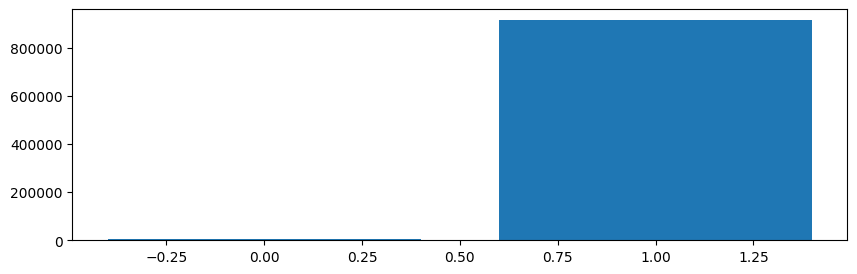

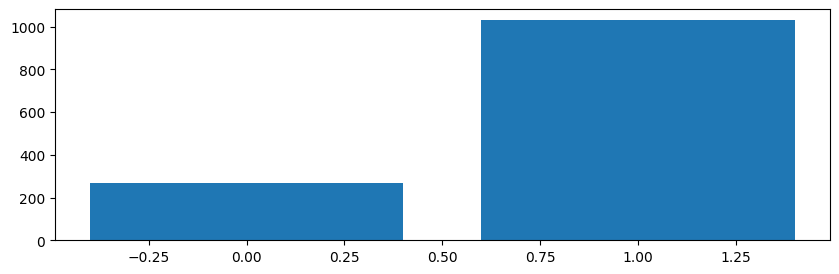

In [100]:
show_class_distribtion(train_pairs.targets)
show_class_distribtion(test_pairs.targets)

Легко видеть, что пар фотографий разных людей гораздо больше, чем пар фотографий одного человека. Это вполне ожидаемо, но, если не предпринять мер, ведет к двум проблемам:
1. Метрика качества предсказаний должна учитывать дисбаланс классов. В частности, accuracy нам не подойдёт. А использовать будем известный из курса машинного обучения AUC-ROC.
2. Нужно "подтюнить" даталоадер тренировочных данных, чтобы в каждый батч попадало примерно одинаковое количество фотографий каждого класса. Иначе победить деградацию модели к "всегда 1" будет очень сложно.

##### [1 балл] Задание 1.3. Стратифицированный даталоадер.

Для начала решим вторую проблему. Нужно сделать такой даталоадер, чтобы в каждом батче количество элементов класса "0" совпадало с количеством элементов класса "1".

Как известно, стандартный класс `DataLoader` в torch имеет много параметров. В частности, параметр `sampler` позволяет гибко управлять выдачей. Изучите [документацию](https://docs.pytorch.org/docs/stable/data.html#data-loading-order-and-sampler) и реализуйте свой семплер, который решит проблему.

В `pytorch_metric_learning` уже есть готовая реализация того, что нам нужно. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.4__.

Соберем Сэмплер, позволяющий получать батчи, внутри которых одинаковое количество пар фотографий одних и тех же и разных людей. Задумка прозрачная и читается легко.
На основе:
1. Документация PyTorch: https://docs.pytorch.org/docs/stable/data.html
2. How to Build a Custom Batch Sampler: https://medium.com/@haleema.ramzan/how-to-build-a-custom-batch-sampler-in-pytorch-ce04161583ee.

In [101]:
class BalancedBatchSampler(torch.utils.data.Sampler):
    def __init__(self, dataset, batch_size):
        self.dataset = dataset
        self.batch_size = batch_size
        self.class_0_indices = []
        self.class_1_indices = []
        for idx in range(len(dataset)):
            label = dataset[idx][2]
            if label == 0:
                self.class_0_indices.append(idx)
            else:
                self.class_1_indices.append(idx)
        self.class_0_indices = np.array(self.class_0_indices)
        self.class_1_indices = np.array(self.class_1_indices)
        self.m_per_class = batch_size // 2
        self.m_batches = min(len(self.class_0_indices), len(self.class_1_indices)) // self.m_per_class
    def __iter__(self):
        np.random.shuffle(self.class_0_indices)
        np.random.shuffle(self.class_1_indices)
        for i in range(self.m_batches):
            batch_0 = self.class_0_indices[i * self.m_per_class:(i + 1) * self.m_per_class]
            batch_1 = self.class_1_indices[i * self.m_per_class:(i + 1) * self.m_per_class]
            batch = np.concatenate([batch_0, batch_1])
            np.random.shuffle(batch)
            for idx in batch:
                yield int(idx)
    def __len__(self):
        return self.m_batches * self.batch_size

In [102]:
sampler = BalancedBatchSampler(train_pairs, batch_size=32)

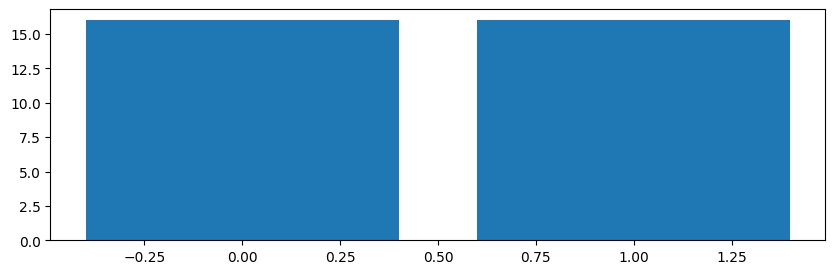

In [103]:
train_pairs_loader = torch.utils.data.DataLoader(
    train_pairs,
    batch_size=32,
    sampler=sampler,
    num_workers=0,  
    pin_memory=True 
)

valid_pairs_loader = torch.utils.data.DataLoader(
    valid_pairs,
    batch_size=64,  
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

test_pairs_loader = torch.utils.data.DataLoader(
    test_pairs,
    batch_size=32,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)

# Убедимся, что теперь выдача равномерная
show_class_distribtion(next(iter(train_pairs_loader))[2])

### [3.5 балла] Часть 2. Классификация.

Начнём с простого: попробуем решить проблему как обычную задачу бинарной классификации. Реализуйте и обучите обычную свёрточную сеть, которая принимает два набора фотографий и предсказывает вероятность, что это фотографии разных людей.

##### [1 балл] Задание 2.1. Модель классификации.

Сначала нужно реализовать модель. В `forward` необходимо принять два батча фотографий. `i`-e число в выводе `forward` должно быть предсказанием для пары из `i`-й фотографии `image1` и `i`-й фотографии `image2`. Подумайте, как это сделать. Возможно, стоит как-нибудь склеить `image1` и `image2`? Или склеить эмбеддинги? А может быть нужен какой-то трешхолд?

Вы вольны использовать любую архитектуру сети. Ассерт в конце ячейки поможет вам убедиться, что модель теоретически делает то, что нужно.

In [112]:
x = next(iter(train_pairs_loader))[0]
x.shape

torch.Size([32, 3, 224, 224])

Основу для модели составил семинар 2 - были внесены лишь минорные изменения в виде:
1. Изменен padding с same на 1
2. Добавление stride для MaxPool2d
3. Добавление Dropout в head часть
4. Использование Average Pool вместо MaxPool в последнем слое
5. Увеличена глубина из-за сложности задачи относительно семинарской
6. Отказ от LazyLinear (костыльность)
7. Эмбеддинги двух изображений конкатенируются, извлекаются признаки, ищутся вероятности - идея: https://www.quora.com/Is-there-a-computer-vision-algorithm-that-compares-two-images-against-one-another-and-returns-a-percentage-of-similarity

In [113]:
class ClassificationNet(nn.Module):
    def __init__(self, image_channels=3):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(image_channels, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d(1)
        )
        self.head = nn.Sequential(
            nn.Dropout(0.5),  
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),  
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 2)
        )
    def forward(self, image1, image2):
        embed_1 = self.get_embedding(image1)
        embed_2 = self.get_embedding(image2)
        conc = torch.cat([embed_1, embed_2], dim=1)
        return self.head(conc)

    def get_embedding(self, x):
        out = self.encoder(x)
        return nn.Flatten()(out)

##### [2 балла] Задание 2.2. Обучение.

Теперь обучите свою модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 2.5 \cdot \dfrac{AucRoc - 0.6}{0.2}, 2.5) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.8`

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1)

In [114]:
model = ClassificationNet().to(device)

В основном используемый здесь алгогритм был взят из семинарского ноутбука / с учетом моей адаптации в домашнем задании 1 по CV. Самостоятельно была произведена актуализация под задачу двух изображений. Динамический отбор и сохранение модели были написаны на основе TensorFlow и документации (https://docs.pytorch.org/tutorials/beginner/saving_loading_models.html - сохранение через .pth).

In [115]:
from tqdm.auto import tqdm
import sys

def training_epoch(model, optimizer, criterion, train_loader, tqdm_desc):
    train_loss = 0.0
    num_samples = 0
    train_correct = 0
    model.train()

    progress_bar = tqdm(train_loader, desc=tqdm_desc, leave=False, ncols=100,
                        dynamic_ncols=True, file=sys.stdout)

    for batch in progress_bar:
        images1, images2, target = batch
        images1 = images1.to(device)
        images2 = images2.to(device)
        targets = target.long().to(device)

        optimizer.zero_grad()
        out = model(images1, images2)
        loss = criterion(out, targets)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * len(images1)
        num_samples += len(images1)

        _, predicted = torch.max(out, 1)
        train_correct += (predicted == targets).sum().item()

        progress_bar.set_postfix({
            'loss': f'{train_loss/num_samples:.4f}',
            'acc': f'{100*train_correct/num_samples:.2f}%'
        })

    train_loss /= num_samples
    train_accuracy = 100 * train_correct / num_samples

    return train_loss, train_accuracy


@torch.no_grad()
def validation_epoch(model, criterion, val_loader, tqdm_desc):
    val_loss = 0.0
    num_samples = 0
    val_correct = 0
    val_preds = []
    val_targets = []

    model.eval()

    progress_bar = tqdm(val_loader, desc=tqdm_desc, leave=False, ncols=100,
                        dynamic_ncols=True, file=sys.stdout)

    for batch in progress_bar:
        images1, images2, target = batch
        images1 = images1.to(device)
        images2 = images2.to(device)
        targets = target.long().to(device)

        out = model(images1, images2)
        loss = criterion(out, targets)

        val_loss += loss.item() * len(images1)
        num_samples += len(images1)

        _, predicted = torch.max(out, 1)
        val_correct += (predicted == targets).sum().item()

        probs = torch.softmax(out, dim=1)[:, 1]
        val_preds.extend(probs.cpu().tolist())
        val_targets.extend(targets.cpu().tolist())

        progress_bar.set_postfix({
            'loss': f'{val_loss/num_samples:.4f}',
            'acc': f'{100*val_correct/num_samples:.2f}%'
        })

    val_loss /= num_samples
    val_accuracy = 100 * val_correct / num_samples
    val_auc = sklearn.metrics.roc_auc_score(val_targets, val_preds)

    return val_loss, val_accuracy, val_auc


def train(model, optimizer, criterion, train_loader, val_loader, epochs, scheduler=None):
    train_losses = []
    val_losses = []
    best_val_auc = 0

    model.to(device)

    for epoch in range(1, epochs + 1):
        print(f"\n{'='*70}")
        print(f"Epoch {epoch}/{epochs}")
        print(f"{'='*70}")

        train_loss, train_acc = training_epoch(
            model, optimizer, criterion, train_loader,
            tqdm_desc=f'[Train]'
        )

        val_loss, val_acc, val_auc = validation_epoch(
            model, criterion, val_loader,
            tqdm_desc=f'[Val]  '
        )

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        if scheduler is not None:
            scheduler.step(val_loss)

        print(f"\nResults:")
        print(f"  Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
        print(f"  Val Loss:   {val_loss:.4f} | Val Acc:   {val_acc:.2f}%")
        print(f"  Val AUC-ROC: {val_auc:.4f}")
        print(f"  LR: {optimizer.param_groups[0]['lr']:.6f}")

        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), 'best_model.pth')
            print(f"  ✓ Best model saved! (AUC: {val_auc:.4f})")

    print(f"\n{'='*70}")
    print(f"Training completed! Best Val AUC-ROC: {best_val_auc:.4f}")
    print(f"{'='*70}\n")

    return train_losses, val_losses

In [116]:
class ModelWithSoftmax(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model

    def forward(self, image1, image2):
        logits = self.base_model(image1, image2)
        probs = torch.softmax(logits, dim=1)
        return probs[:, 1]

    def get_embedding(self, x):
        return self.base_model.get_embedding(x)

model_for_eval = ModelWithSoftmax(model).to(device)

In [117]:
def get_score(auc_roc):
    return max(0, min(2.5 * (auc_roc - 0.6) / 0.2, 2.5))

def get_auc_roc(your_model):
    preds = []
    targets = []
    your_model.eval()
    for images1, images2, labels in tqdm(test_pairs_loader):
        with torch.no_grad():
            output = your_model(images1.to(device), images2.to(device))
        preds.extend(output.detach().cpu().tolist())
        targets.extend(labels.detach().cpu().tolist())
    preds = np.array(preds)
    targets = np.array(targets)
    return sklearn.metrics.roc_auc_score(targets, preds)

In [118]:
set_random_seed(42)
model = nn.DataParallel(ClassificationNet().to(device))

NUM_EPOCHS = 20
LR = 0.000317

optimizer = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=1e-6)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.75, patience=2)
criterion = nn.CrossEntropyLoss()

train_losses, val_losses = train(
    model,
    optimizer,
    criterion,
    train_pairs_loader,
    valid_pairs_loader,
    epochs=NUM_EPOCHS,
    scheduler=scheduler
)


Epoch 1/20


[Train]:   0%|          | 0/403 [00:00<?, ?it/s]

[Val]  :   0%|          | 0/176 [00:00<?, ?it/s]


Results:
  Train Loss: 0.6935 | Train Acc: 50.85%
  Val Loss:   0.6775 | Val Acc:   52.44%
  Val AUC-ROC: 0.6386
  LR: 0.000317
  ✓ Best model saved! (AUC: 0.6386)

Epoch 2/20


[Train]:   0%|          | 0/403 [00:00<?, ?it/s]

...

[Val]  :   0%|          | 0/176 [00:00<?, ?it/s]


Results:
  Train Loss: 0.6212 | Train Acc: 64.76%
  Val Loss:   0.6210 | Val Acc:   63.04%
  Val AUC-ROC: 0.7810
  LR: 0.000100

Epoch 20/20


[Train]:   0%|          | 0/403 [00:00<?, ?it/s]

[Val]  :   0%|          | 0/176 [00:00<?, ?it/s]


Results:
  Train Loss: 0.6231 | Train Acc: 64.67%
  Val Loss:   0.6378 | Val Acc:   61.18%
  Val AUC-ROC: 0.7888
  LR: 0.000075
  ✓ Best model saved! (AUC: 0.7888)

Training completed! Best Val AUC-ROC: 0.7888



In [119]:
model = ClassificationNet()
state_dict = torch.load('best_model.pth', map_location=device)
new_state_dict = {}
for k, v in state_dict.items():
    if k.startswith('module.'):
        new_state_dict[k[7:]] = v  
    else:
        new_state_dict[k] = v  

model.load_state_dict(new_state_dict, strict=True)
model.to(device)
model.eval()

model_for_eval = ModelWithSoftmax(model)

auc_roc = get_auc_roc(model_for_eval)
test_score = get_score(auc_roc)
print(get_auc_roc(model_for_eval))
print(f"Test Score: {test_score:.4f}")

  0%|          | 0/41 [00:00<?, ?it/s]

  0%|          | 0/41 [00:00<?, ?it/s]

0.8022775385064603
Test Score: 2.5000


##### [0.5 балла] Задание 2.3. Анализ и отчет.

Опишите свои эксперименты. Проанализируйте результаты. Почему результаты получились не очень хорошими? Может быть, решать задачу через бинарную классификацию - не лучшая идея? Приведите не менее 3 аргументов, почему это так.

Изначально я использовал подход с нормализованными и аугментированными изображениями, чтобы модель быстрее сходилась и искала качественные признаки. Я использовал learning schedule, чтобы модель динамически понижала learning rate. Я обратил внимание, что изначально выбранный learning rate быстро понижался и попробовал запустить модель с изначально более низким learning rate и за одно с еще более низким weight decay (не совсем правильно исправлять два гиперпараметра, однако в данном случае я был уверен на 99% из-за schedule, что понижение learning rate необходимо и оказался прав), что привело к наилучшему результату на валидации.

Тем не менее, решение задачи через бинарную классификацию представяется не лучшей идеей (что видно по метрике качества классификации). На основе процесса обучения могу сказать следующее:
1) Наиболее очевидный недостаток - сильный дисбаланс классов. Да, в некоторой мере он сглаживается BatchSampler, но в итоге получается балансированных батчей меньше на трейне, чем несбалансированных на валидации (363 против 396), при том, что на валидацию бралось лишь 15% обучающей выборки. Подобный результат не располагает к высоким результатам при использовании бинарной классификации, когда речь идет о таких сложных объектах как изображения.
2) Бинарная классификация явно не подразумевает насколько изображения далеки или близки - лишь вероятности на основе порога. При этом весьма полезна информация о градациях - картинки похожи сильно, умеренно, совсем не похожи и тому подобное.
3) Из этого вытекает и следующий недостаток - так как модель учится на конкретных парах людей с признаками похожи/не похожи, то при добавлении в базу новых людей ее необходимо полностью переучитывать, формируя новые пары. С учетом невозможности судить о степени дальности двух изображений - это говорит о непринимости метода в реальных задачах. Обощительная способность признаков, извлекаемых моделью - в лучшем случае посредственна, что отражается на невысоком, даже с учетом всех ухищерений, AUC-ROC.

Необходим качественно иной подход для эффективного решения задачи.

### [5 баллов] Часть 3. Распознавание лиц.

Теперь попробуем использовать более хитрые методы, которые лучше подходят для решаемой задачи. В частности, триплетную функцию потерь. Далее наша модель будет не предсказывать вероятность для двух картинок, а формировать эмбеддинги для одной картинки таким образом, чтобы эмбеддинги фотографий одного человека были близки, а разных людей - далеки.

##### [2 балла] Задание 3.1. Триплетная функция потерь.

Напомним теорию. Пусть $A$ - произвольное изображение; $P$ - изображение того же человека (позитивный пример); $N$ - изображение любого другого человека (негативный пример); $f$ - наша нейронная сеть; $\alpha$ - гиперпараметр, отвечающий за желаемый “отступ” – расстояние между латентными представлениями изображений разных людей. Тогда функционал ошибки определяется следующим образом:

$$ L(A, P, N) = max(||f(A) - f(P)|| - ||f(A) - f(N)|| + \alpha, 0) $$

В этом задании вам необходимо реализовать этот функционал. Для удобства в дальнейшем, предлагается сразу реализовать batch-версию. Таким образом, на входе должно быть 2 параметра:
- Набор эмбеддингов размера (batch_size, embedding_size)
- Набор классов (номера людей, чьи это фотографии) размера (batch_size)

Ваша функция должна найти все тройки $(A, P, N)$ и вычислить лосс для них.

В `pytorch_metric_learning` уже есть готовая реализация. Вы можете её найти и использовать. Но в таком случае __максимальный балл за это задание - 0.5__.

За основу взята эта реализация: https://medium.com/@Skpd/triplet-loss-on-imagenet-dataset-a2b29b8c2952
Расстояние вычисляется как евклидова норма матрицы эмбеддингов.

In [104]:
class TripletLoss(nn.Module):
    def __init__(self, margin=1.0):
        super(TripletLoss, self).__init__()
        self.margin = margin
    def forward(self, embeddings, labels):
        batch_size = embeddings.size(0)
        distances = torch.cdist(embeddings, embeddings, p=2)
        positive = labels.unsqueeze(1) == labels.unsqueeze(0)
        nond_mask = ~torch.eye(batch_size, batch_size).bool()
        positive_mask = positive & nond_mask
        negative_mask = labels.unsqueeze(1) != labels.unsqueeze(0)
        losses = []
        for A in range(len(labels)):
          P = positive_mask[A].nonzero(as_tuple=True)[0]
          N = negative_mask[A].nonzero(as_tuple=True)[0]
          positive_distances = distances[A, P]
          negative_distances = distances[A, N]
          loss = positive_distances.unsqueeze(1) - negative_distances.unsqueeze(0) + self.margin
          loss_A = torch.relu(loss)
          losses.append(loss_A.view(-1))
        return torch.cat(losses).mean()

In [17]:
criterion = TripletLoss(0.25)

In [18]:
# Вы можете использовать этот ассерт в качестве теста
embeddings = torch.tensor([
    [ 1., 2, 3 ],
    [ 1, 3, 4 ],
    [ 4, 5, 6 ]
])
labels = torch.tensor([ 1., 2, 1 ])
assert (criterion(embeddings, labels) - 2.6775) < 1e-4

##### [3 балла] Задание 3.2. Обучение.

Теперь обучите модель и добейтесь приемлемого качества. Балл за это задание вычисляется по формуле:

$$ clamp(0, 3 \cdot \dfrac{AucRoc - 0.8}{0.15}, 3) $$

То есть, для получения полного балла за это задание необходимо добиться AUC-ROC `0.95`

При необходимости, вы можете улучшить функцию потерь. Например, учитывать не все тройки, а только "сложные", как это умеет делать реализация в `pytorch_metric_learning`. Также подумайте над даталоадером. Возможно, имеет смысл брать в батч одинаковое количество фотографий каждого человека по аналгии с заданием 1.3? Тем не менее имейте в виду, что для получения полного балла за задание, вы должны реализовать все модификации самостоятельно, а не использовать готовые.

__При использовани предобученных моделей, балл за это задание умножается на 0.5__ (то есть, не более 1.5) \
__При использовани pytorch_metric_learning, балл за это задание уменьшается на 0.5 за каждое использование__

##### [0.1 балла] Бонус: распознай себя

В качестве бонуса, загрузите свою фотографию (можно не одну), пропустите ее через модель и определите, на кого из известных людей, по мнению модели, вы больше всего похоже.

In [ ]:
### YOUR CODE HERE ###